<div class = "alert alert-success", align="center", >
<strong>Proyecto Machine Learning - Predicción de precios Airbnb</strong>
</div>

## 🎯 Objetivos del Análisis

El objetivo de esta práctica es construir un modelo de Machine Learning capaz de predecir el precio de un Airbnb utilizando datos reales obtenidos mediante scraping.

## 📒 Librerías


In [1]:
import pandas as pd
import numpy as np
import dtale
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn import preprocessing
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

<div class = "alert alert-success", align="center", >
<strong> 🗃️ Cargar Datos </strong>
</div>



In [2]:
df = pd.read_csv("/Users/Admin/Documents/BootcampKeepCoding/Machine-Learning-101/data/airbnb-listings-extract.csv", sep=';', engine='c')
df.head()

,ID,Listing Url,Scrape ID,Last Scraped,Name,Summary,Space,Description,Experiences Offered,Neighborhood Overview,...,Review Scores Communication,Review Scores Location,Review Scores Value,License,Jurisdiction Names,Cancellation Policy,Calculated host listings count,Reviews per Month,Geolocation,Features
0,11210388,https://www.airbnb.com/rooms/11210388,20170306202425,2017-03-07,The Loft-Full Bath-Deck w/View,Loft in the Hill country 12-15 minutes directl...,This loft has a spectacular view of the hills ...,Loft in the Hill country 12-15 minutes directl...,none,This neighborhood is located in the hills west...,...,10.0,10.0,10.0,NaN,NaN,moderate,1.0,3.50,"30.3373609355,-97.8632766782","Host Is Superhost,Host Has Profile Pic,Host Id..."
1,17471131,https://www.airbnb.com/rooms/17471131,20170407214050,2017-04-08,"Claris I, Friendly Rentals","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...",none,Plaza Cataluña Catalonia Square is the large...,...,10.0,8.0,10.0,HUTB-006721,NaN,super_strict_30,106.0,0.86,"41.3896829422,2.17262543017","Host Has Profile Pic,Requires License,Instant ..."
2,17584891,https://www.airbnb.com/rooms/17584891,20170407214050,2017-04-08,"Style Terrace Red, Friendly Rentals","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...",none,Plaza Cataluña Catalonia Square is the large...,...,NaN,NaN,NaN,HUTB-007527,NaN,super_strict_30,106.0,NaN,"41.3930345489,2.16217327868","Host Has Profile Pic,Requires License,Instant ..."
3,5398030,https://www.airbnb.com/rooms/5398030,20170407214050,2017-04-08,Picasso Suite 1.4 Paseo de Gracia,Live like a local in Barcelona's most chic dis...,You wake up to the sun rising over Barcelona's...,Live like a local in Barcelona's most chic dis...,none,We're right in the heart of the chic L'Eixampl...,...,10.0,10.0,9.0,NaN,NaN,strict,24.0,1.09,"41.3969668101,2.1674178103","Host Has Profile Pic,Host Identity Verified,Re..."
4,18104606,https://www.airbnb.com/rooms/18104606,20170407214050,2017-04-08,Smart City Centre Apartment II,"Unique apartment in vibrant neighborhoods, car...","License: HUTB-005313 Charming apartment, locat...","Unique apartment in vibrant neighborhoods, car...",none,NaN,...,NaN,NaN,NaN,NaN,NaN,flexible,92.0,NaN,"41.3886851936,2.15514963616","Host Has Profile Pic,Host Identity Verified,Is..."


<div class = "alert alert-success", align="center", >
<strong> 🛠️ Exploración de los datos </strong>
</div>


In [3]:
# Exploracion de datos
display(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14780 entries, 0 to 14779
Data columns (total 89 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              14780 non-null  int64  
 1   Listing Url                     14780 non-null  object 
 2   Scrape ID                       14780 non-null  int64  
 3   Last Scraped                    14780 non-null  object 
 4   Name                            14779 non-null  object 
 5   Summary                         14189 non-null  object 
 6   Space                           10888 non-null  object 
 7   Description                     14774 non-null  object 
 8   Experiences Offered             14780 non-null  object 
 9   Neighborhood Overview           9134 non-null   object 
 10  Notes                           5644 non-null   object 
 11  Transit                         9066 non-null   object 
 12  Access                          

None

In [4]:
#Validamos los datos de las columnas
df.columns

Index(['ID', 'Listing Url', 'Scrape ID', 'Last Scraped', 'Name', 'Summary',
       'Space', 'Description', 'Experiences Offered', 'Neighborhood Overview',
       'Notes', 'Transit', 'Access', 'Interaction', 'House Rules',
       'Thumbnail Url', 'Medium Url', 'Picture Url', 'XL Picture Url',
       'Host ID', 'Host URL', 'Host Name', 'Host Since', 'Host Location',
       'Host About', 'Host Response Time', 'Host Response Rate',
       'Host Acceptance Rate', 'Host Thumbnail Url', 'Host Picture Url',
       'Host Neighbourhood', 'Host Listings Count',
       'Host Total Listings Count', 'Host Verifications', 'Street',
       'Neighbourhood', 'Neighbourhood Cleansed',
       'Neighbourhood Group Cleansed', 'City', 'State', 'Zipcode', 'Market',
       'Smart Location', 'Country Code', 'Country', 'Latitude', 'Longitude',
       'Property Type', 'Room Type', 'Accommodates', 'Bathrooms', 'Bedrooms',
       'Beds', 'Bed Type', 'Amenities', 'Square Feet', 'Price', 'Weekly Price',
       'Month

In [5]:
#Verificamos la forma del DataFrame
df.shape

(14780, 89)

In [6]:
#Utilizamos dtale para mostrar los datos de forma que podamos explorarlos de la mejor manera
dtale.show(df)

In [7]:
#Validamos los datos de las columnas
df.columns

Index(['ID', 'Listing Url', 'Scrape ID', 'Last Scraped', 'Name', 'Summary',
       'Space', 'Description', 'Experiences Offered', 'Neighborhood Overview',
       'Notes', 'Transit', 'Access', 'Interaction', 'House Rules',
       'Thumbnail Url', 'Medium Url', 'Picture Url', 'XL Picture Url',
       'Host ID', 'Host URL', 'Host Name', 'Host Since', 'Host Location',
       'Host About', 'Host Response Time', 'Host Response Rate',
       'Host Acceptance Rate', 'Host Thumbnail Url', 'Host Picture Url',
       'Host Neighbourhood', 'Host Listings Count',
       'Host Total Listings Count', 'Host Verifications', 'Street',
       'Neighbourhood', 'Neighbourhood Cleansed',
       'Neighbourhood Group Cleansed', 'City', 'State', 'Zipcode', 'Market',
       'Smart Location', 'Country Code', 'Country', 'Latitude', 'Longitude',
       'Property Type', 'Room Type', 'Accommodates', 'Bathrooms', 'Bedrooms',
       'Beds', 'Bed Type', 'Amenities', 'Square Feet', 'Price', 'Weekly Price',
       'Month

In [8]:
# Eliminamos filas sin precio (target)
df = df.dropna(subset=['Price']).copy()
print(f"Registros con precio disponible: {len(df)}")

Registros con precio disponible: 14763


## Eliminar columnas

Se eliminan variables con tipo de texto libre, URL, debido por su baja contribución para el modelo predictivo.
- **URLs e identificadores** (`Thumbnail Url`,
    `Medium Url`,
    `XL Picture Url`,
    `Picture Url`,
    `Listing Url`,
    `Host URL`,
    `Host Picture Url`,
    `Host Thumbnail Url`) referencias en la base de datos
- **Texto libre** (`Transit`,
    `Neighborhood Overview`,
    `Host About`,
    `House Rules`,
    `Space`,
    `Summary`,
    `Amenities`,
    `Description`,
    `Features`,
    `Name`) Se debe utilizar tecnicas de NLP 
- **Geografía y fechas redundantes** (` `Smart Location`,
    `Street`,
    `Host Name`,
    `Calendar Updated`,
    `Calendar last Scraped`,
    `Last Scraped`) su información ya está recogida en columnas  más limpias como `Neighbourhood Cleansed`.

In [9]:
drop_cols = [
    'Thumbnail Url',
    'Medium Url',
    'XL Picture Url',
    'Picture Url',
    'Listing Url',
    'Host URL',
    'Host Picture Url',
    'Host Thumbnail Url', 
    'Transit',
    'Neighborhood Overview',
    'Host About',
    'House Rules',
    'Space',
    'Summary',
    'Amenities',
    'Description',
    'Features',
    'Name',    
    'ID',
    'Host ID',
    'Scrape ID',    
    'Smart Location',
    'Street',
    'Host Name',
    'Calendar Updated',
    'Calendar last Scraped',
    'Last Scraped',  
    'Neighbourhood',
    'Host Neighbourhood',
    'Notes',
    'Access',
    'Interaction',
    'Host Verifications',
    'Experiences Offered',
    'Host Listings Count', 
    'Host Total Listings Count',
    'Neighbourhood Group Cleansed',
    'Country', 
    'Country Code', 
    'State', 
    'Market',
    'Bed Type', 
    'Zipcode',
    'Host Since', 
    'First Review', 
    'Last Review',
    'Geolocation',
]


df_clear = df.drop(columns=[col for col in drop_cols if col in df.columns])
print(f"Columnas tras este paso: {df_clear.shape[1]}")

df_clear.head().T


Columnas tras este paso: 42


,0,1,2,3,4
Host Location,My father was USAF so I was born at Offutt AFB...,"Barcelona, Catalonia, Spain","Barcelona, Catalonia, Spain","Barcelona, Cataluña, Spain","Madrid, Community of Madrid, Spain"
Host Response Time,within an hour,within an hour,within an hour,within an hour,within an hour
Host Response Rate,100.0,100.0,100.0,100.0,99.0
Host Acceptance Rate,NaN,NaN,NaN,NaN,NaN
Neighbourhood Cleansed,78733,la Dreta de l'Eixample,la Dreta de l'Eixample,la Dreta de l'Eixample,l'Antiga Esquerra de l'Eixample
City,Austin,Barcelona,Barcelona,Barcelona,Barcelona
Latitude,30.337361,41.389683,41.393035,41.396967,41.388685
Longitude,-97.863277,2.172625,2.162173,2.167418,2.15515
Property Type,Loft,Apartment,Apartment,Apartment,Apartment
Room Type,Entire home/apt,Entire home/apt,Entire home/apt,Entire home/apt,Entire home/apt


In [10]:
df_clear['City'] = df_clear['City'].str.strip()  # quitar espacios
df_clear['City'] = df_clear['City'].replace({
    'Madrid': 'Madrid', 
    'madrid': 'Madrid', 
    'MADRID': 'Madrid', 
    '马德里': 'Madrid',
    'Madrid, Spain': 'Madrid'
})
df_clear['City'].value_counts()

City
Madrid         13260
Barcelona        292
London           132
Paris            107
Palma             49
               ...  
Mascot             1
Aravaca            1
Cala Murada        1
Son Vida           1
Pina               1
Name: count, Length: 242, dtype: int64

<div class = "alert alert-success", align="center", >
<strong> 📋 División Train / Test </strong>
</div>



Se divide el dataset **antes** de realizar operaciones estadisticas para garantizar que el conjunto de test permanezca completamente asilado en el proceso de limpieza y modelado.

Se usa el 80% en entrenamiento y 20% para la evaluación final para la reproductivilidad

In [11]:
X_full = df_clear.drop(columns=['Price'])
y_full = df_clear['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")
print(f"Columnas: {X_train.shape[1]}")

Train: 11810 filas | Test: 2953 filas
Columnas: 41


<div class = "alert alert-success", align="center", >
<strong>  📊  Limpieza estadística / Train </strong>
</div>



## Eliminación de columnas con valores por debajo del 40%

Al validar el dataset encontramos que tiene varios datos nulos, entonces para reducir el ruido establecemos un **umbral del 40%** donde cualquier columnas que tenga sus registros nulos superiores a 40% seran eliminados 

In [12]:
UMBRAL = 0.40  


missing_pct_train = X_train.isnull().mean()

cols_to_keep   = missing_pct_train[missing_pct_train < UMBRAL].index
cols_to_drop   = missing_pct_train[missing_pct_train >= UMBRAL].index

# Aplicar la misma selección a train y test
X_train = X_train[cols_to_keep]
X_test  = X_test[cols_to_keep]

print(f"🗑️ Columnas eliminadas (≥{UMBRAL*100:.0f}% nulos): {len(cols_to_drop)}")
print(f"✅ Columnas conservadas: {len(cols_to_keep)}")
print(f"📊 Forma → Train: {X_train.shape} | Test: {X_test.shape}")

🗑️ Columnas eliminadas (≥40% nulos): 9
✅ Columnas conservadas: 32
📊 Forma → Train: (11810, 32) | Test: (2953, 32)


In [13]:
X_train.head().T

,1955,9268,7788,2942,10702
Host Location,"Madrid, Community of Madrid, Spain","Madrid, Community of Madrid, Spain","Santiago Metropolitan Region, Chile","Madrid, Madrid, Spain","Madrid, Community of Madrid, Spain"
Host Response Time,within an hour,within a few hours,within a day,within an hour,within an hour
Host Response Rate,100.0,90.0,90.0,100.0,100.0
Neighbourhood Cleansed,Cuatro Caminos,Justicia,Delicias,Palacio,Argüelles
City,Madrid,Madrid,Madrid,Madrid,Madrid
Latitude,40.449447,40.422629,40.399026,40.412766,40.420672
Longitude,-3.7001,-3.697382,-3.692876,-3.707591,-3.71522
Property Type,Apartment,Apartment,Apartment,Apartment,Apartment
Room Type,Entire home/apt,Private room,Private room,Private room,Entire home/apt
Accommodates,2,2,2,2,2


<div class = "alert alert-success", align="center", >
<strong>  📊  Imputacion de datos </strong>
</div>

In [14]:
# Verifiquemos los tipos de columnas
num_cols = X_train.select_dtypes(include='number').columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
print(f"Columnas numéricas: {len(num_cols)} | Columnas categóricas: {len(cat_cols)}")


Columnas numéricas: 25 | Columnas categóricas: 7


In [15]:
# 1Identificar columnas por tipo
cols_num = X_train.select_dtypes(include=['number']).columns
cols_cat = X_train.select_dtypes(include=['object', 'category']).columns
print(f"Columnas numéricas: {len(cols_num)} | Columnas categóricas: {len(cols_cat)}")

# Imputar numéricas con MEDIANA 
for col in cols_num:
    if X_train[col].isnull().any():
        valor = X_train[col].median()
        valor = 0 if pd.isna(valor) else valor 
        X_train[col] = X_train[col].fillna(valor)
        X_test[col]  = X_test[col].fillna(valor)

# Imputar categóricas con MODA 
for col in cols_cat:
    if X_train[col].isnull().any():
        moda = X_train[col].mode()
        valor = moda[0] if len(moda) > 0 else 'Desconocido'
        X_train[col] = X_train[col].fillna(valor)
        X_test[col]  = X_test[col].fillna(valor)

print(f"   Nulos restantes en Train: {X_train.isnull().sum().sum()}")
print(f"   Nulos restantes en Test:  {X_test.isnull().sum().sum()}")

Columnas numéricas: 25 | Columnas categóricas: 7
   Nulos restantes en Train: 0
   Nulos restantes en Test:  0


In [16]:
X_train.shape

(11810, 32)

In [17]:
# Codificación One-Hot (solo se ajusta en train, se aplica en ambos)
X_train = pd.get_dummies(X_train, columns=cols_cat, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=cols_cat, drop_first=True)

# Alinear columnas 
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f"Datos listo para modelar: {X_train.shape[0]} features")

Datos listo para modelar: 11810 features


<div class = "alert alert-success", align="center", >
<strong>  📊  Analisis exploratorio dstribución del precio </strong>
</div>

In [18]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# SUBCONJUNTO DE TRAIN
price_train = y_train.copy()

# 1. Estadísticas básicas
print("ESTADÍSTICAS DE PRICE (solo train):")
print(price_train.describe())
print(f"\nCoef. de variación: {price_train.std() / price_train.mean() * 100:.1f}%")
print(f"Asimetría: {price_train.skew():.2f}")
print(f"   → {'Cola derecha (sesgo positivo)' if price_train.skew() > 0.5 else '⚠️Distribución relativamente simétrica'}")

ESTADÍSTICAS DE PRICE (solo train):
count    11810.000000
mean        73.985605
std         73.010942
min          9.000000
25%         34.000000
50%         55.000000
75%         87.000000
max        999.000000
Name: Price, dtype: float64

Coef. de variación: 98.7%
Asimetría: 4.37
   → Cola derecha (sesgo positivo)


Al validar la informacion podemos concluir que la variable **Price** presenta una asimetrai hacia la derecha con un coheficiente asimetrico del 4.37 y una variacion del 98.7%, lo cual no permite indicar que tiene una dispersion muy alta respecto a la media, el precio medio es de **73.99** la media se situa en **55**, con un max **999.00** donde podemos confirmar que los valores extremos aumenta la media. Para esto entonces haremos una **Transformacion logaritmica en el precio** para disminuir el sesgo para poder tener una distribucion normal y un **tratamiento en los outlier** los valores extremos por envima del IQR donde seran filtrados del conjunto de datos de Train para disminuir las distorsion

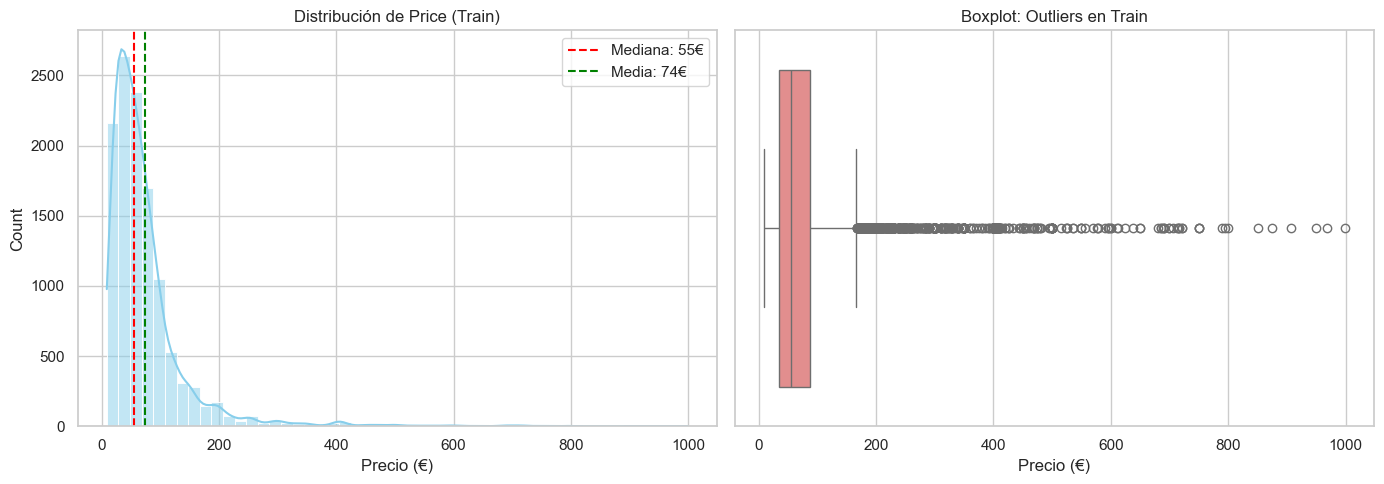

In [19]:
# 2. Visualización: histograma + boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma 
sns.histplot(x=price_train, bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].axvline(price_train.median(), color='red', linestyle='--', label=f"Mediana: {price_train.median():.0f}€")
axes[0].axvline(price_train.mean(), color='green', linestyle='--', label=f"Media: {price_train.mean():.0f}€")
axes[0].set_title('Distribución de Price (Train)')
axes[0].set_xlabel('Precio (€)')
axes[0].legend()

# Boxplot para outliers
sns.boxplot(x=price_train, ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot: Outliers en Train')
axes[1].set_xlabel('Precio (€)')

plt.tight_layout()
plt.show()

In [20]:
# 3. Detección de outliers con IQR
Q1 = price_train.quantile(0.25)
Q3 = price_train.quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

outliers = price_train[(price_train < limite_inf) | (price_train > limite_sup)]
print(f"\n🔍 OUTLIERS EN TRAIN (método IQR):")
print(f"   Rango 'normal': {limite_inf:.0f}€ - {limite_sup:.0f}€")
print(f"   Outliers detectados: {len(outliers)} ({len(outliers)/len(price_train)*100:.2f}%)")

#Transformar el precio en log para reducir asimetría
if price_train.skew() > 1:
    print(f"\n✅ Recomendación: Usar np.log1p(Price) para modelar")
    print(f"   Asimetría original: {price_train.skew():.2f}")
    
    # Mostrar cómo quedaría transformado
    log_price = np.log1p(price_train)
    print(f"Asimetría con log: {log_price.skew():.2f}")
else:
    print(f"\n⚠️ Price tiene asimetría moderada")


🔍 OUTLIERS EN TRAIN (método IQR):
   Rango 'normal': -46€ - 166€
   Outliers detectados: 771 (6.53%)

✅ Recomendación: Usar np.log1p(Price) para modelar
   Asimetría original: 4.37
Asimetría con log: 0.39


📈 COMPARATIVA DE DISTRIBUCIÓN:
• RAW   → Media: 74€ | Mediana: 55€ | Skew: 4.37
• LOG   → Media: 4.05 | Mediana: 4.03 | Skew: 0.39


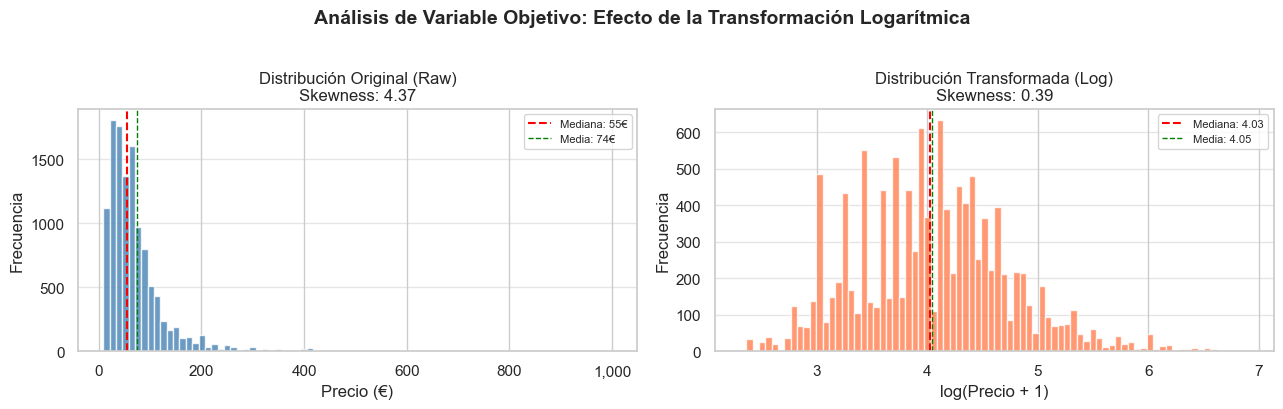


✅ CONCLUSIÓN Y DECISIÓN:
   🎯 La asimetría original (4.37) es alta.
   🎯 La transformación reduce la asimetría a 0.39 (casi normal).
   🚀 DECISIÓN: Usar 'log(Price+1)' como target para el entrenamiento del modelo.


In [21]:

# Estadísticas comparativas (siempre visibles)
print(f"📈 COMPARATIVA DE DISTRIBUCIÓN:")
print(f"• RAW   → Media: {price_train.mean():.0f}€ | Mediana: {price_train.median():.0f}€ | Skew: {price_train.skew():.2f}")

# Calcular log_price 
log_price = np.log1p(price_train)
print(f"• LOG   → Media: {log_price.mean():.2f} | Mediana: {log_price.median():.2f} | Skew: {log_price.skew():.2f}")

# Gráficas 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))


axes[0].hist(price_train, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(price_train.median(), color='red', linestyle='--', linewidth=1.5, label=f"Mediana: {price_train.median():.0f}€")
axes[0].axvline(price_train.mean(), color='green', linestyle='--', linewidth=1, label=f"Media: {price_train.mean():.0f}€")
axes[0].set_title(f'Distribución Original (Raw)\nSkewness: {price_train.skew():.2f}')
axes[0].set_xlabel('Precio (€)')
axes[0].set_ylabel('Frecuencia')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.5)


axes[1].hist(log_price, bins=80, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(log_price.median(), color='red', linestyle='--', linewidth=1.5, label=f"Mediana: {log_price.median():.2f}")
axes[1].axvline(log_price.mean(), color='green', linestyle='--', linewidth=1, label=f"Media: {log_price.mean():.2f}")
axes[1].set_title(f'Distribución Transformada (Log)\nSkewness: {log_price.skew():.2f}')
axes[1].set_xlabel('log(Precio + 1)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.5)

# Ajustes finales y guardado
plt.suptitle('Análisis de Variable Objetivo: Efecto de la Transformación Logarítmica', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_price_dist_raw_vs_log.png', bbox_inches='tight', dpi=300)  
plt.show()

# Decisión automática basada en datos
print(f"\n✅ CONCLUSIÓN Y DECISIÓN:")
if price_train.skew() > 1:
    print(f"   🎯 La asimetría original ({price_train.skew():.2f}) es alta.")
    print(f"   🎯 La transformación reduce la asimetría a {log_price.skew():.2f} (casi normal).")
    print(f"   🚀 DECISIÓN: Usar 'log(Price+1)' como target para el entrenamiento del modelo.")
  
else:
    print(f"   ⚠️ La asimetría original ({price_train.skew():.2f}) es moderada.")
    print(f"   ⚠️ La transformación no mejora drásticamente la forma ({log_price.skew():.2f})")


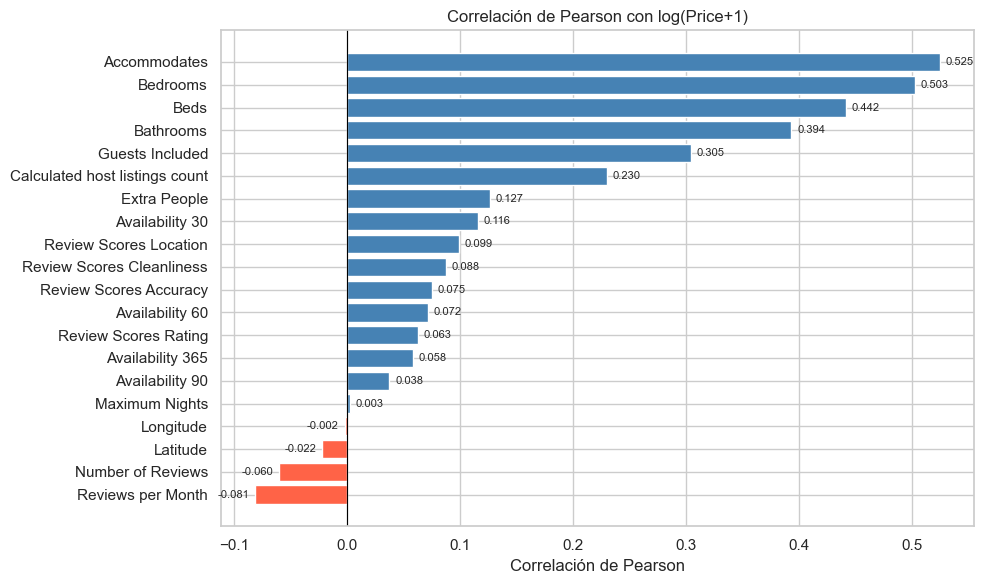


las 10 variables más correlacionadas con el precio:
Accommodates                      0.524833
Bedrooms                          0.502842
Beds                              0.441504
Bathrooms                         0.393513
Guests Included                   0.304778
Calculated host listings count    0.229968
Extra People                      0.127017
Availability 30                   0.116156
Review Scores Location            0.099181
Review Scores Cleanliness         0.087809
Review Scores Accuracy            0.075357
Availability 60                   0.071550
Review Scores Rating              0.063121
Availability 365                  0.058464
Availability 90                   0.037671
Review Scores Communication       0.031229
Minimum Nights                    0.020680
Review Scores Checkin             0.019603
Host Response Rate                0.009696
Review Scores Value               0.003180


In [22]:
# ── Correlación de variables numéricas con log(Price) ───────────
cols_num_analysis = X_train.select_dtypes(include='number').columns

corr_series = (X_train[cols_num_analysis]
               .corrwith(price_train)
               .dropna()
               .sort_values(ascending=False))


top_pos = corr_series.head(15)
top_neg = corr_series.tail(5)
top_all = pd.concat([top_pos, top_neg])

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if v >= 0 else 'tomato' for v in top_all.values]
bars = ax.barh(top_all.index[::-1], top_all.values[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de Pearson con log(Price+1)', fontsize=12)
ax.set_xlabel('Correlación de Pearson')

for bar, val in zip(bars, top_all.values[::-1]):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

print("\nlas 10 variables más correlacionadas con el precio:")
print(corr_series.head(20).to_string())


Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best CV score (neg MSE): -0.236
✅ Best alpha: 0.1


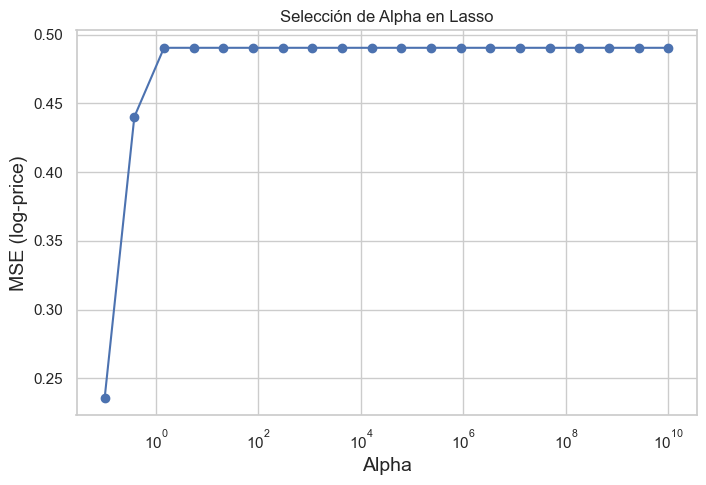


📊 MÉTRICAS FINALES (escala original):
MAE  (test): 27.00 €
RMSE (test): 58.77 €
R²   (test): 0.255

🔍 VARIABLES SELECCIONADAS POR LASSO (6):
Accommodates                  : +0.1478
Bedrooms                      : +0.0667
Host Location_CN              : +0.0424
City_Madrid                   : -0.0283
Room Type_Private room        : -0.2379
Room Type_Shared room         : -0.0320


In [23]:
# Target en escala log 
y_train_log = np.log1p(y_train)

# Escalar features 
scaler = preprocessing.StandardScaler().fit(X_train)
XtrainScaled = scaler.transform(X_train)
XtestScaled  = scaler.transform(X_test)

# GridSearchCV para encontrar el mejor alpha
alpha_vector = np.logspace(-1, 10, 20) 
param_grid = {'alpha': alpha_vector}

grid = GridSearchCV(
    Lasso(), 
    scoring='neg_mean_squared_error', 
    param_grid=param_grid, 
    cv=5,         
    verbose=1,     
    n_jobs=-1     
)
grid.fit(XtrainScaled, y_train_log)  

print(f"✅ Best CV score (neg MSE): {grid.best_score_:.3f}")
print(f"✅ Best alpha: {grid.best_params_['alpha']}")

# 📈 Gráfica Alpha vs MSE
scores = -1 * np.array(grid.cv_results_['mean_test_score'])
plt.figure(figsize=(8,5))
plt.semilogx(alpha_vector, scores, '-o')
plt.xlabel('Alpha', fontsize=14)
plt.ylabel('MSE (log-price)', fontsize=14)
plt.title('Selección de Alpha en Lasso')
plt.grid(True)
plt.show()

# Entrenar modelo final con alpha óptimo
alpha_optimo = grid.best_params_['alpha']
lasso = Lasso(alpha=alpha_optimo, max_iter=10000).fit(XtrainScaled, y_train_log)

# Predicciones 
ytrain_pred_log = lasso.predict(XtrainScaled)
ytest_pred_log  = lasso.predict(XtestScaled)

# escala original (€) para métricas reales de negocio
ytrain_pred = np.expm1(ytrain_pred_log)
ytest_pred  = np.expm1(ytest_pred_log)

# Métricas finales 
mae_test  = mean_absolute_error(y_test, ytest_pred)
mse_test  = mean_squared_error(y_test, ytest_pred)
r2_test   = r2_score(y_test, ytest_pred)

print(f'\n📊 MÉTRICAS FINALES (escala original):')
print(f'MAE  (test): {mae_test:.2f} €')
print(f'RMSE (test): {np.sqrt(mse_test):.2f} €')
print(f'R²   (test): {r2_test:.3f}')

# Ver coeficientes / variables seleccionadas
feature_names = X_train.columns 
print(f'\n🔍 VARIABLES SELECCIONADAS POR LASSO ({np.sum(lasso.coef_ != 0)}):')
for f, w in zip(feature_names, lasso.coef_):
    if w != 0:  
        print(f'{f:30s}: {w:+.4f}')

Se utilizó Lasso (regularización L1) para la selección automática de variables

Encontramos que variables como Accomodates, betrooms,bets y bathrooms tienen una correlacion alta donde podemos determinar que el precio es influenciado por el espacio, y su capacidad, ademas guests Included yextra people tiene una relacion menos determinante referente al precio. Validamos las features con lasso y encontramos que accomodates y betrooms son variables que nos pueden ayudar a predecir el precio, ya que tienen una correlacion mayor al 30% y variables que lasso descarto como reviw scores y availability tienen una correlacon menor al 10%

In [24]:
mask = lasso.coef_ != 0
selected_features = X_train.columns[mask].tolist()

print(f"\n✅ Variables seleccionadas por Lasso (coef ≠ 0): {len(selected_features)}")
print(f"Variables:\n {selected_features}")

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]




✅ Variables seleccionadas por Lasso (coef ≠ 0): 6
Variables:
 ['Accommodates', 'Bedrooms', 'Host Location_CN', 'City_Madrid', 'Room Type_Private room', 'Room Type_Shared room']


In [25]:
print(X_train_sel.columns)
print(X_test_sel.columns)

Index(['Accommodates', 'Bedrooms', 'Host Location_CN', 'City_Madrid',
       'Room Type_Private room', 'Room Type_Shared room'],
      dtype='object')
Index(['Accommodates', 'Bedrooms', 'Host Location_CN', 'City_Madrid',
       'Room Type_Private room', 'Room Type_Shared room'],
      dtype='object')


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Modelo final sobre las variables seleccionadas
model_final = GradientBoostingRegressor(
    n_estimators=200, 
    max_depth=4, 
    learning_rate=0.03, 
    random_state=42
)
model_final.fit(X_train_sel, y_train_log) 

# Predicción y evaluación en €
y_pred_log = model_final.predict(X_test_sel)
y_pred = np.expm1(y_pred_log)

mae_final = mean_absolute_error(y_test, y_pred)
r2_final  = r2_score(y_test, y_pred)

print(f"🏆 MODELO FINAL (Test ciego):")
print(f"   MAE: {mae_final:.2f}€ | R²: {r2_final:.3f}")

🏆 MODELO FINAL (Test ciego):
   MAE: 24.28€ | R²: 0.427


🔍 Buscando mejores hiperparámetros para GradientBoosting...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ learning_rate óptimo: 0.2
✅ n_estimators óptimo: 50
📊 Mejor CV MSE (log): 0.1777


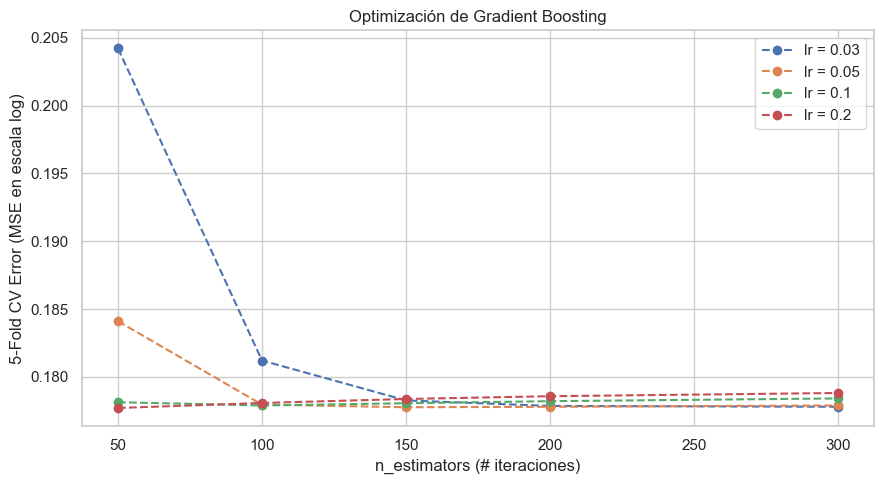


🏆 MODELO FINAL (Test ciego - escala original):
   MAE: 24.36€ | R²: 0.425
   📈 R² (log) → Train: 0.647 | Test: 0.612


In [35]:
learning_rate = [0.03, 0.05, 0.1, 0.2]
n_estimators  = [50, 100, 150, 200, 300]

param_grid_gb = {
    'learning_rate': learning_rate,
    'n_estimators': n_estimators
}

# GridSearchCV se usa target log y features seleccionadas por Lasso
gbr_base = GradientBoostingRegressor(
    max_depth=3, 
    min_samples_leaf=5, 
    random_state=42
)

grid_gb = GridSearchCV(
    estimator=gbr_base,
    param_grid=param_grid_gb,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

print("🔍 Buscando mejores hiperparámetros para GradientBoosting...")
grid_gb.fit(X_train_sel, y_train_log)  

# Extraemos los mejores parámetros
lrOptimo = grid_gb.best_params_['learning_rate']
neOptimo = grid_gb.best_params_['n_estimators']
print(f"\n✅ learning_rate óptimo: {lrOptimo}")
print(f"✅ n_estimators óptimo: {neOptimo}")
print(f"📊 Mejor CV MSE (log): {-grid_gb.best_score_:.4f}")

# Preparar datos para la gráfica

errors = -grid_gb.cv_results_['mean_test_score']

error_matrix = errors.reshape(len(learning_rate), len(n_estimators))

# Gráfica
plt.figure(figsize=(9, 5))
for i, lr in enumerate(learning_rate):
    plt.plot(n_estimators, error_matrix[i, :], '--o', label=f'lr = {lr}')

plt.legend()
plt.xlabel('n_estimators (# iteraciones)')
plt.ylabel('5-Fold CV Error (MSE en escala log)')
plt.title('Optimización de Gradient Boosting')
plt.grid(True)
plt.tight_layout()
plt.show()

# Entrenar modelo final con los mejores parámetros
bt = GradientBoostingRegressor(
    random_state=42,
    max_depth=3,
    learning_rate=lrOptimo,
    n_estimators=neOptimo,
    min_samples_leaf=5
)
bt.fit(X_train_sel, y_train_log)

# Evaluar en TEST
y_pred_log = bt.predict(X_test_sel)
y_pred = np.expm1(y_pred_log)

mae_final = mean_absolute_error(y_test, y_pred)
r2_final  = r2_score(y_test, y_pred)

# Título de la gráfica 
r2_train_log = bt.score(X_train_sel, y_train_log)
r2_test_log  = bt.score(X_test_sel, np.log1p(y_test))

print(f"\n🏆 MODELO FINAL (Test ciego - escala original):")
print(f"   MAE: {mae_final:.2f}€ | R²: {r2_final:.3f}")
print(f"   📈 R² (log) → Train: {r2_train_log:.3f} | Test: {r2_test_log:.3f}")

Entonces podremos indicar que los hiperparametros mediantes GridSearchCV, identifico que se debe tomar valores de **learning_rate=0.2** y **n_estimators=50**. El erro del CV muestra que la convergencia es estable entre los 100 y 150 arboles, el algoritmo seleciono 50 el cual se puede concluir qe puede ser para mamntener la precision. El modelo obtuvo un R2 DE 0.425 Y un MAE de 24.36. La brecha de R2 en entramiento y test es de 0.035 donde podemos manifestar que tiene ausencia de sobreajuste. Utilizamos Lasso para optener los features para poder modelarlo con Gradiente Boosting

📊 REPORTE FINAL DE RESULTADOS - AIRBNB PRICE PREDICTION

🏆 MÉTRICAS FINALES (Escala Original - Euros):
   • MAE (Error Medio Absoluto): 24.36 €
   • RMSE (Raíz Error Cuadrático): 51.66 €
   • R² (Varianza Explicada): 0.425

📈 MÉTRICAS EN ESCALA LOG (Para diagnóstico técnico):
   • R² Train (log): 0.647
   • R² Test  (log): 0.612
   • Brecha Train-Test: 0.035 → ✅ Sin overfitting

⚙️ CONFIGURACIÓN ÓPTIMA (GridSearchCV):
   • learning_rate: 0.2
   • n_estimators: 50
   • max_depth: 3
   • Features usadas (6): ['Accommodates', 'Bedrooms', 'Host Location_CN', 'City_Madrid', 'Room Type_Private room', 'Room Type_Shared room']


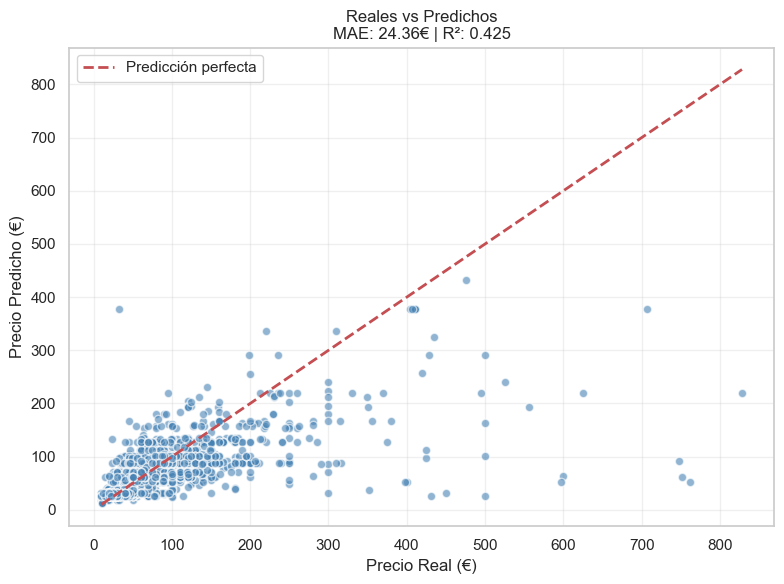

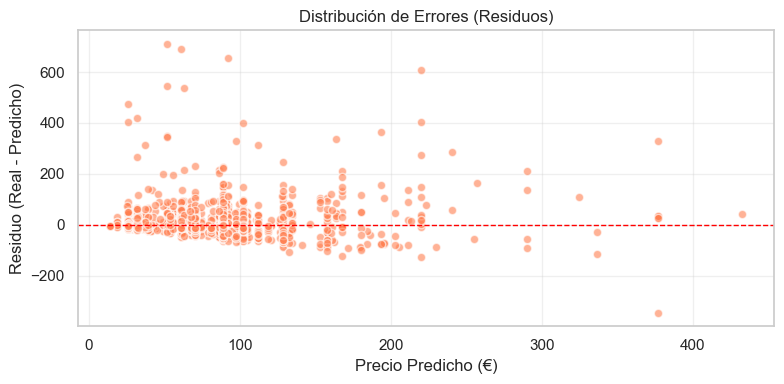

In [43]:
print("="*60)
print("📊 REPORTE FINAL DE RESULTADOS - AIRBNB PRICE PREDICTION")
print("="*60)


y_pred = np.expm1(bt.predict(X_test_sel))

# Calcular métricas clave
mae_final = mean_absolute_error(y_test, y_pred)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred))
r2_final = r2_score(y_test, y_pred)
r2_train_log = bt.score(X_train_sel, y_train_log)
r2_test_log = bt.score(X_test_sel, np.log1p(y_test))

# IMPRIMIR MÉTRICAS PRINCIPALES
print(f"\n🏆 MÉTRICAS FINALES (Escala Original - Euros):")
print(f"   • MAE (Error Medio Absoluto): {mae_final:.2f} €")
print(f"   • RMSE (Raíz Error Cuadrático): {rmse_final:.2f} €")
print(f"   • R² (Varianza Explicada): {r2_final:.3f}")

print(f"\n📈 MÉTRICAS EN ESCALA LOG (Para diagnóstico técnico):")
print(f"   • R² Train (log): {r2_train_log:.3f}")
print(f"   • R² Test  (log): {r2_test_log:.3f}")
print(f"   • Brecha Train-Test: {abs(r2_train_log - r2_test_log):.3f} → {'✅ Sin overfitting' if abs(r2_train_log - r2_test_log) < 0.05 else '⚠️ Revisar'}")

# IMPRIMIR CONFIGURACIÓN DEL MODELO
print(f"\n⚙️ CONFIGURACIÓN ÓPTIMA (GridSearchCV):")
print(f"   • learning_rate: {lrOptimo}")
print(f"   • n_estimators: {neOptimo}")
print(f"   • max_depth: 3")
print(f"   • Features usadas ({len(selected_features)}): {selected_features}")


# MOSTRAR GRÁFICAS (Solo visualización, NO guardado)


# Gráfica 1: Reales vs Predichos
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor='white', color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción perfecta')
plt.xlabel('Precio Real (€)')
plt.ylabel('Precio Predicho (€)')
plt.title(f'Reales vs Predichos\nMAE: {mae_final:.2f}€ | R²: {r2_final:.3f}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()  # ← Muestra en ventana, NO guarda archivo

# Gráfica 2: Residuos
residuos = y_test - y_pred
plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuos, alpha=0.6, edgecolor='white', color='coral')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Precio Predicho (€)')
plt.ylabel('Residuo (Real - Predicho)')
plt.title('Distribución de Errores (Residuos)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()  

Con Lasso pudimos encontar las 6 variables para predecir el precio, se puede deteerminar que al final lo que mas marca el precio es el espacio dentro de cada piso y su capacidad de poder convivir la cantidad de personas dentro de un apartamento o casa. Se puede determinar que consas como reviews y disponibilidad no aportan mucho en el caso.

Con el modelo de Gradient Boosting mejoro bastante respecto a Lasso, porque pasamos de 25% de variavilidad a un 42%, sin tener en en cuenta otros factores. en cuanto el error medio de 24 podemos que si un apartamento cuesta 50 este se podria acerta +-24 que es el rango de referencia. 